### Reconstruction of subcircuits

Write a Circuit

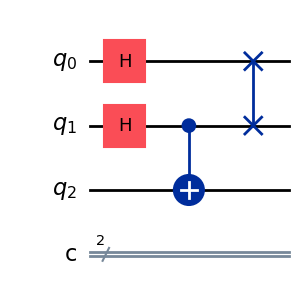

In [39]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit_ibm_runtime import SamplerV2, Batch
from qiskit_aer.primitives import EstimatorV2
 
from qiskit_addon_cutting.instructions import Move, CutWire
from qiskit_addon_cutting import (
    partition_problem,
    generate_cutting_experiments,
    cut_wires,
    expand_observables,
    reconstruct_expectation_values,
)
 
 
qc_0 = QuantumCircuit(3,2)
for i in range(2):
    qc_0.h(i)

qc_0.cx(1,2)
qc_0.swap(0,1)

# qc_0.measure([2,1],[0,1])
 
# # Define observable
# observable = SparsePauliOp(["ZII", "IZI"])
 
# Draw circuit
qc_0.draw("mpl")

Read subcircuits

In [11]:
import os
from collections import defaultdict
from qiskit import qpy

folder = "saved_data/subcircuits"

circuits_dict = defaultdict(list)

for fname in sorted(os.listdir(folder)):
    if not fname.endswith(".qpy"):
        continue

    # filename format: group_<key>_<index>.qpy
    _, key, idx = fname.replace(".qpy", "").split("_")
    key = int(key)

    with open(os.path.join(folder, fname), "rb") as f:
        circuits = qpy.load(f)   # returns a list
        circuits_dict[key].append(circuits[0])  # single circuit per file

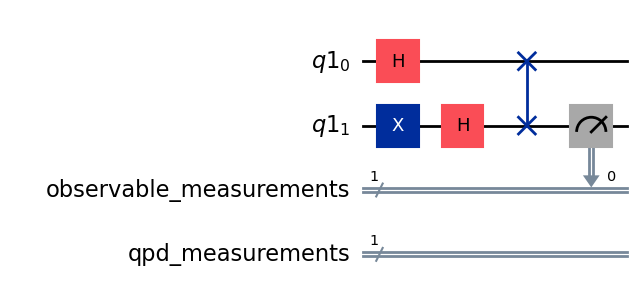

In [12]:
with open("saved_data/subcircuits/group_0_3.qpy", "rb") as f:
    circuits = qpy.load(f)
circuits[0].draw()

In [13]:
circuits_dict

defaultdict(list,
            {0: [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1890dc620>,
             1: [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x189099cd0>,
              <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x189174350>]})

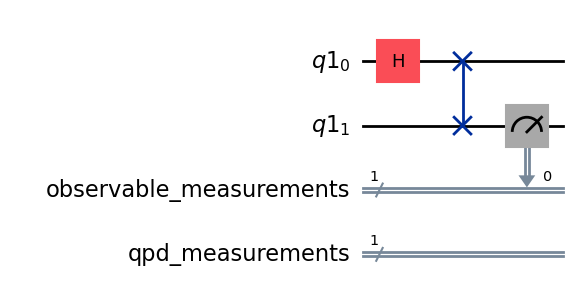

In [4]:
circuits_dict[0][0].draw()

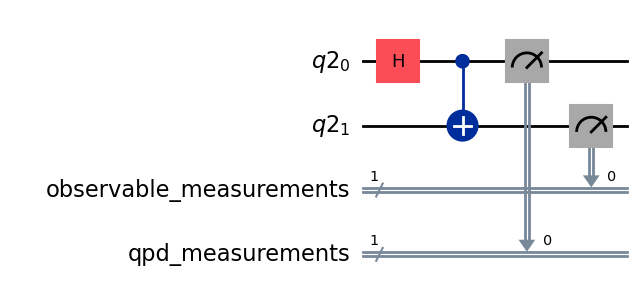

In [5]:
circuits_dict[1][6].draw()

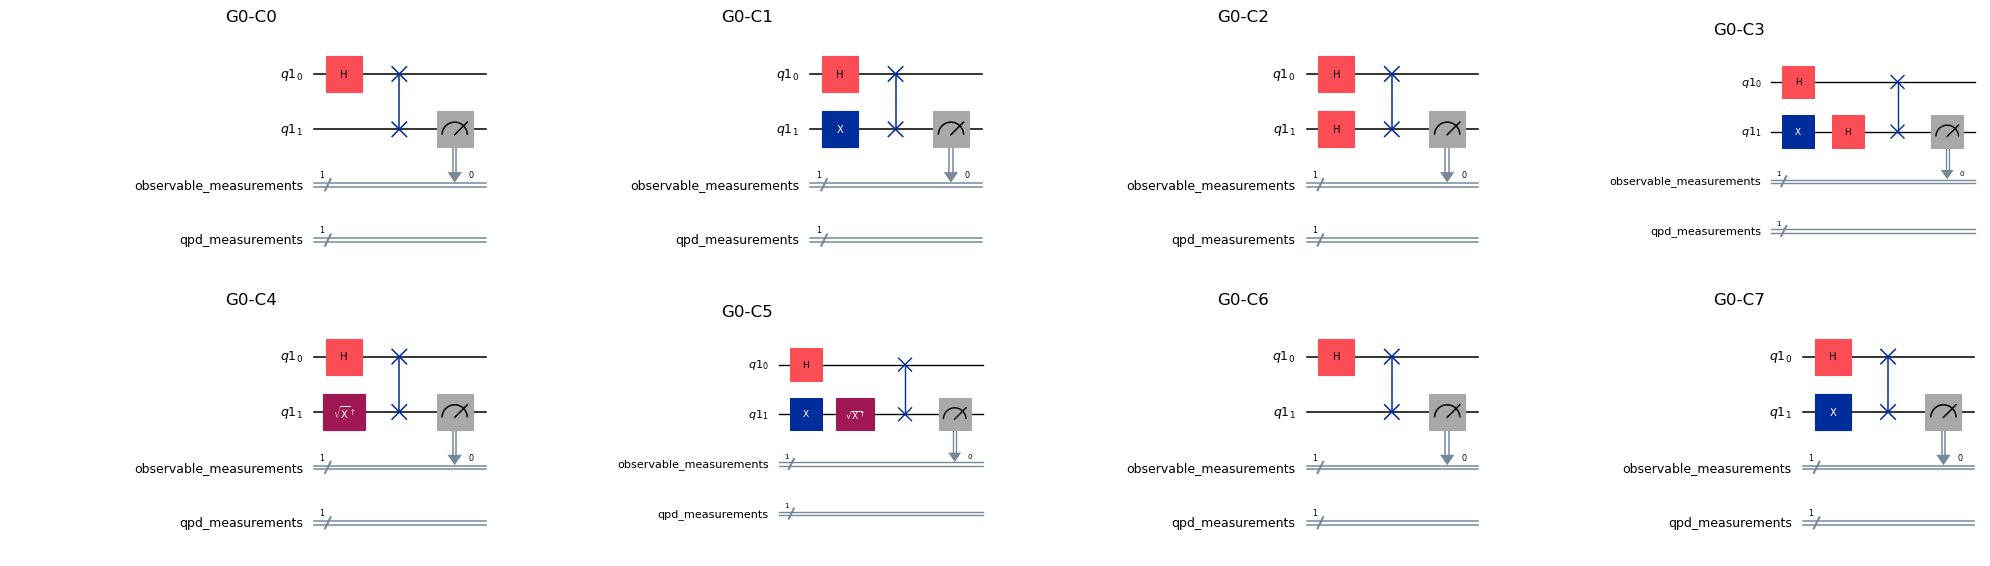

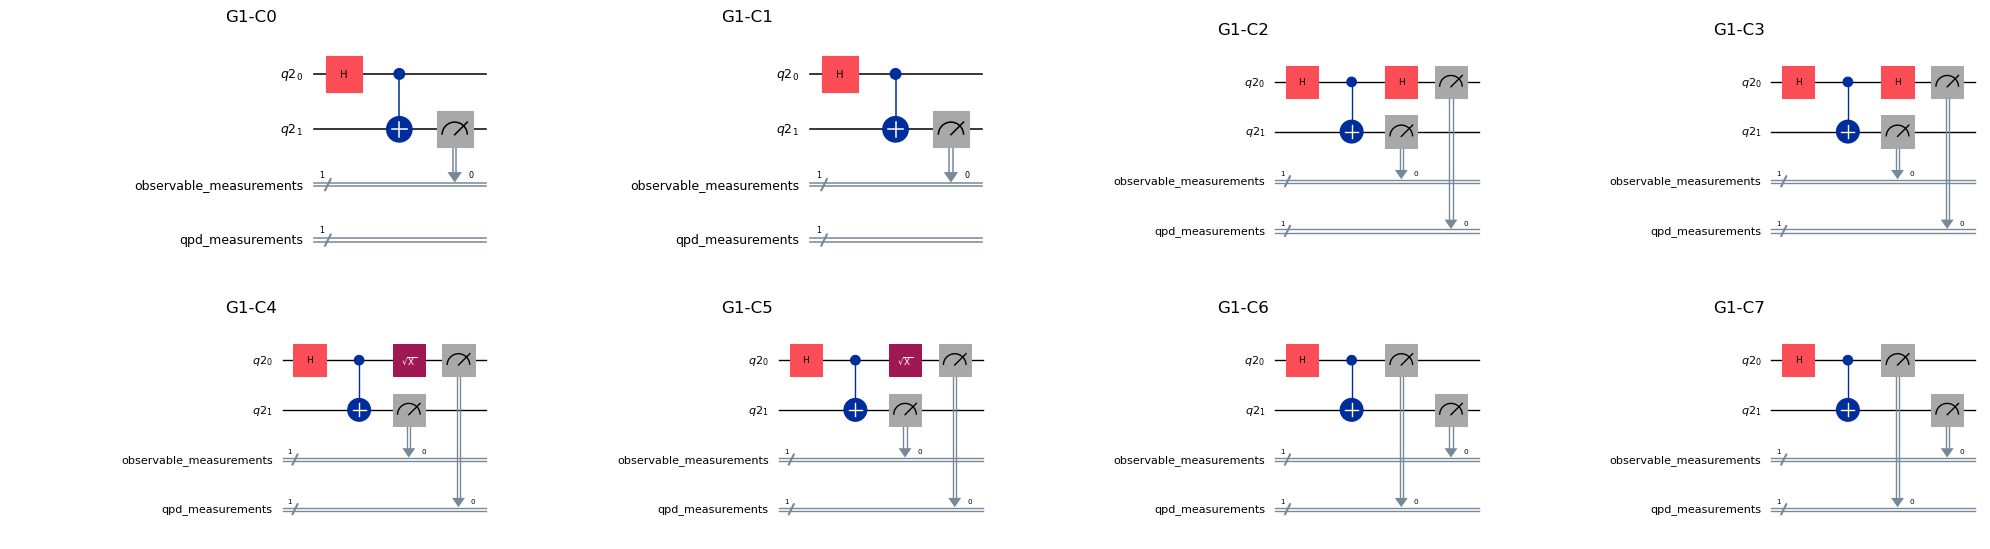

In [14]:
import math
import matplotlib.pyplot as plt
from qiskit.visualization import circuit_drawer

data = circuits_dict  # your defaultdict

for k, qcs in data.items():

    n = len(qcs)
    cols = 4
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3*rows))

    # Make axes always 2D
    if rows == 1:
        axes = [axes]

    for idx, qc in enumerate(qcs):
        r = idx // cols
        c = idx % cols
        circuit_drawer(qc, output="mpl", ax=axes[r][c], fold=-1)
        axes[r][c].set_title(f"G{k}-C{idx}")

    # Hide empty subplots
    for idx in range(n, rows * cols):
        r = idx // cols
        c = idx % cols
        axes[r][c].axis("off")

    plt.tight_layout()
    plt.show()


Run subcircuits on a fakebackend

In [ ]:
# Set a backend to use and transpile the subexperiments
backend = FakeManilaV2()
pass_manager = generate_preset_pass_manager(
    optimization_level=1, backend=backend
)
isa_subexperiments = {
    label: pass_manager.run(partition_subexpts)
    for label, partition_subexpts in circuits_dict.items()
}
 
# Submit each partition's subexperiments to the Qiskit Runtime Sampler
# primitive, in a single batch so that the jobs will run back-to-back.
# with Batch(backend=backend) as batch:
#     sampler = SamplerV2(mode=batch)
#     jobs = {
#         label: sampler.run(subsystem_subexpts, shots=2**12)
#         for label, subsystem_subexpts in isa_subexperiments.items()
#     }
#     # Retrieve results
#     results = {label: job.result() for label, job in jobs.items()}

In [28]:
import time

job_infos = {}

with Batch(backend=backend) as batch:
    sampler = SamplerV2(mode=batch)
    jobs = {}

    for label, subsystem_subexpts in isa_subexperiments.items():
        t_submit = time.perf_counter()
        job = sampler.run(subsystem_subexpts, shots=2**12)
        jobs[label] = (job, t_submit)

    results = {}
    for label, (job, t_submit) in jobs.items():
        result = job.result()
        t_done = time.perf_counter()
        results[label] = result

        info = {
            "wall_clock_latency_sec": t_done - t_submit,
            "job_id": job.job_id(),
        }

        job_infos[label] = info

for label, info in job_infos.items():
    print(f"\n===== {label} =====")
    for k, v in info.items():
        print(k, ":", v)


===== 0 =====
wall_clock_latency_sec : 0.6097178750205785
job_id : b700e1d6-239e-4967-970a-a06f892ff414

===== 1 =====
wall_clock_latency_sec : 0.5608691250672564
job_id : f9dfe7ea-1fd4-4db0-9953-b6c7fe45ea6e


In [40]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

sv = Statevector.from_instruction(qc)

QiskitError: 'Cannot apply instruction with classical bits: measure'

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

sv = Statevector.from_instruction(qc_0)

Statevector([0.5+0.j, 0. +0.j, 0.5+0.j, 0. +0.j, 0. +0.j, 0.5+0.j, 0. +0.j,
             0.5+0.j],
            dims=(2, 2, 2))


In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

single_circuit_times = {}

for label, subsystem_subexpts in circuits_dict.items():
    for label, subsystem_subexpts in isa_subexperiments.items():
        t_submit = time.perf_counter()
        sv = Statevector.from_instruction(subsystem_subexpts[0])
        t_done = time.perf_counter()

        info = {
            "wall_clock_latency_sec": t_done - t_submit,
            "job_id": f"statevector_{label}",
        }

        job_infos[label] = info


for label, info in job_infos.items():
    print(f"\n===== {label} =====")
    for k, v in info.items():
        print(k, ":", v)


QiskitError: 'Cannot apply instruction with classical bits: measure'

In [54]:
import time
from qiskit.quantum_info import Statevector

job_infos = {}
results = {}

for label, subsystem_subexpts in circuits_dict.items():
    t_start = time.perf_counter()
    statevectors = []

    for i, qc in enumerate(subsystem_subexpts):
        qc_no_meas = qc.remove_final_measurements(inplace=False)
        t_start = time.perf_counter()
        sv = Statevector(qc_no_meas)
        t_end = time.perf_counter()
        statevectors.append(sv)
        single_circuit_times[(label, i)] =  t_end - t_start
    results[label] = statevectors

for (label, i), dt in single_circuit_times.items():
    print(f"label {label}, circuit {i}: {dt:.6f} s")


label 0, circuit 0: 0.001629 s
label 0, circuit 1: 0.001403 s
label 0, circuit 2: 0.000814 s
label 0, circuit 3: 0.000596 s
label 0, circuit 4: 0.000343 s
label 0, circuit 5: 0.000509 s
label 0, circuit 6: 0.000323 s
label 0, circuit 7: 0.000694 s
label 1, circuit 0: 0.000493 s
label 1, circuit 1: 0.000413 s
label 1, circuit 2: 0.000392 s
label 1, circuit 3: 0.000365 s
label 1, circuit 4: 0.000347 s
label 1, circuit 5: 0.000405 s
label 1, circuit 6: 0.000295 s
label 1, circuit 7: 0.000272 s


In [55]:
for label, subsystem_subexpts in circuits_dict.items():
    t_start = time.perf_counter()
    statevectors = []

    for i, qc in enumerate(subsystem_subexpts):
        qc_no_meas = qc.remove_final_measurements(inplace=False)
        print(qc_no_meas)

                    ┌───┐   
              q1_0: ┤ H ├─X─
                    └───┘ │ 
              q1_1: ──────X─
                            
qpd_measurements: 1/════════
                            
                    ┌───┐   
              q1_0: ┤ H ├─X─
                    ├───┤ │ 
              q1_1: ┤ X ├─X─
                    └───┘   
qpd_measurements: 1/════════
                            
                    ┌───┐   
              q1_0: ┤ H ├─X─
                    ├───┤ │ 
              q1_1: ┤ H ├─X─
                    └───┘   
qpd_measurements: 1/════════
                            
                    ┌───┐        
              q1_0: ┤ H ├──────X─
                    ├───┤┌───┐ │ 
              q1_1: ┤ X ├┤ H ├─X─
                    └───┘└───┘   
qpd_measurements: 1/═════════════
                                 
                     ┌───┐     
              q1_0: ─┤ H ├───X─
                    ┌┴───┴─┐ │ 
              q1_1: ┤ √Xdg ├─X─
                    └────

In [34]:
import time

job_infos = {}

with Batch(backend=backend) as batch:
    sampler = SamplerV2(mode=batch)
    jobs = {}
    new_subsystem_subexpts = []
    for label, subsystem_subexpts in isa_subexperiments.items():
        new_subsystem_subexpts += subsystem_subexpts

    t_submit = time.perf_counter()
    job = sampler.run(new_subsystem_subexpts, shots=2**12)
    jobs[label] = (job, t_submit)
    result = job.result()
    t_done = time.perf_counter()
    results[label] = result

    info = {
        "wall_clock_latency_sec": t_done - t_submit,
        "job_id": job.job_id(),
    }

    job_infos[label] = info

for label, info in job_infos.items():
    print(f"\n===== {label} =====")
    for k, v in info.items():
        print(k, ":", v)


===== 1 =====
wall_clock_latency_sec : 0.3570255000377074
job_id : 9e8a43e3-5543-41b2-8205-6596be199be0


In [21]:
isa_subexperiments

{0: [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x189edbc80>,
 1: [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x189c812e0>,
  <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x18a183b60>]}

In [23]:
import time

single_circuit_times = {}

with Batch(backend=backend) as batch:
    sampler = SamplerV2(mode=batch)

    for label, circuits in isa_subexperiments.items():
        for i, qc in enumerate(circuits):
            t0 = time.perf_counter()
            job = sampler.run([qc], shots=2**12)
            _ = job.result()
            t1 = time.perf_counter()

            single_circuit_times[(label, i)] = t1 - t0

for (label, i), dt in single_circuit_times.items():
    print(f"label {label}, circuit {i}: {dt:.6f} s")

label 0, circuit 0: 0.214878 s
label 0, circuit 1: 0.391611 s
label 0, circuit 2: 0.187419 s
label 0, circuit 3: 0.187023 s
label 0, circuit 4: 0.202035 s
label 0, circuit 5: 0.302436 s
label 0, circuit 6: 0.182879 s
label 0, circuit 7: 0.183614 s
label 1, circuit 0: 0.288660 s
label 1, circuit 1: 0.191466 s
label 1, circuit 2: 0.184335 s
label 1, circuit 3: 0.183699 s
label 1, circuit 4: 0.296315 s
label 1, circuit 5: 0.185542 s
label 1, circuit 6: 0.185032 s
label 1, circuit 7: 0.183743 s


In [19]:
import time

results = {}
job_times = {}

with Batch(backend=backend) as batch:
    sampler = SamplerV2(mode=batch)
    jobs = {}

    for label, subsystem_subexpts in isa_subexperiments.items():
        t0 = time.perf_counter()
        job = sampler.run(subsystem_subexpts, shots=2**12)
        jobs[label] = (job, t0)

    for label, (job, t0) in jobs.items():
        result = job.result()
        t1 = time.perf_counter()
        results[label] = result
        job_times[label] = t1 - t0

for label, dt in job_times.items():
    print(f"{label}: {dt:.6f} s")

0: 0.695918 s
1: 0.675707 s


Read subobservables

In [17]:
import os
import json
from qiskit.quantum_info import PauliList

folder = "saved_data/subobservables"

objectives = {}

for fname in sorted(os.listdir(folder)):
    if not fname.startswith("objective") or not fname.endswith(".json"):
        continue

    # objective0.json → 0
    idx = int(fname.replace("objective", "").replace(".json", ""))

    with open(os.path.join(folder, fname), "r") as f:
        labels = json.load(f)          # ['II', 'ZI']

    objectives[idx] = PauliList(labels)

Read coefficients

In [18]:
import json
from qiskit_addon_cutting.qpd import WeightType  # wherever WeightType lives

with open("saved_data/coefficients/coefficients.json", "r") as f:
    data = json.load(f)

coefficients = [(v, WeightType(w)) for v, w in data]

subcircuit_results + coefficients + subobservables -> reconstructed expectation value

In [19]:
reconstructed_expval_terms = reconstruct_expectation_values(
    results,
    coefficients,
    objectives,
)
# Apply the coefficients of the original observable
reconstructed_expval = np.dot(reconstructed_expval_terms, observable.coeffs)
 
 
# Compute the exact expectation value using the `qiskit_aer` package.
estimator = EstimatorV2()
exact_expval = estimator.run([(qc_0, observable)]).result()[0].data.evs
print(
    f"Reconstructed expectation value: {np.real(np.round(reconstructed_expval, 3))}"
)
print(f"Exact expectation value: {np.round(exact_expval, 3)}")
print(
    f"Error in estimation: {np.real(np.round(reconstructed_expval-exact_expval, 3))}"
)
print(
    f"Relative error in estimation: {np.real(np.round((reconstructed_expval-exact_expval) / exact_expval, 8))}"
)

Reconstructed expectation value: 0.074
Exact expectation value: 0.0
Error in estimation: 0.074
Relative error in estimation: inf


/var/folders/l8/z9twtlsx6815m7383kbwwymm0000gn/T/ipykernel_67800/66081791.py:21: RuntimeWarning: divide by zero encountered in divide
  f"Relative error in estimation: {np.real(np.round((reconstructed_expval-exact_expval) / exact_expval, 8))}"
/var/folders/l8/z9twtlsx6815m7383kbwwymm0000gn/T/ipykernel_67800/66081791.py:21: RuntimeWarning: invalid value encountered in divide
  f"Relative error in estimation: {np.real(np.round((reconstructed_expval-exact_expval) / exact_expval, 8))}"


### Generate Subcircuits

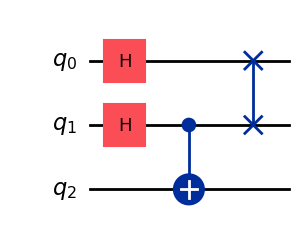

In [23]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit_ibm_runtime import SamplerV2, Batch
from qiskit_aer.primitives import EstimatorV2
 
from qiskit_addon_cutting.instructions import Move, CutWire
from qiskit_addon_cutting import (
    partition_problem,
    generate_cutting_experiments,
    cut_wires,
    expand_observables,
    reconstruct_expectation_values,
)
 
 
qc_0 = QuantumCircuit(3)
for i in range(2):
    qc_0.h(i)

qc_0.cx(1,2)
qc_0.swap(0,1)

 
# Define observable
observable = SparsePauliOp(["ZII", "IZI"])
 
# Draw circuit
qc_0.draw("mpl")

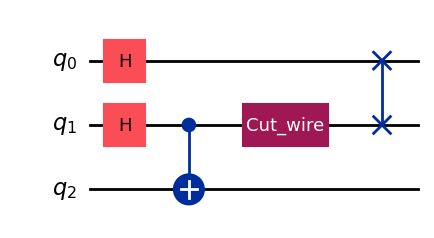

In [24]:
qc_1 = QuantumCircuit(3)
for i in range(2):
    qc_1.h(i)

qc_1.cx(1,2)
qc_1.append(CutWire(), [1])
qc_1.swap(0,1)
 
qc_1.draw("mpl")

Expanded Observable: ['ZIII', 'IZII']


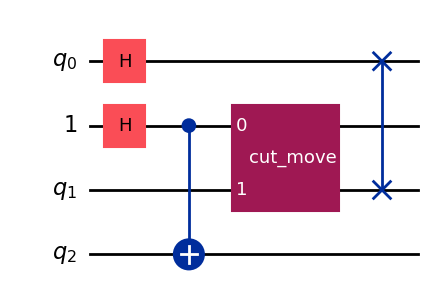

In [25]:
# Transform CutWire instructions to Move instructions
qc_2 = cut_wires(qc_1)
 
# Expand the observable to match the new circuit size
expanded_observable = expand_observables(observable.paulis, qc_0, qc_2)
print(f"Expanded Observable: {expanded_observable}")
qc_2.draw("mpl")

Subobservables to measure: 
{0: PauliList(['II', 'ZI']), 1: PauliList(['ZI', 'II'])}

Sampling overhead: 16.0


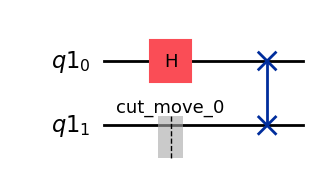

In [26]:
partitioned_problem = partition_problem(
    circuit=qc_2,
    observables=expanded_observable,
)
subcircuits = partitioned_problem.subcircuits
subobservables = partitioned_problem.subobservables
bases = partitioned_problem.bases
 
print(f"Subobservables to measure: \n{subobservables}\n")
print(f"Sampling overhead: {np.prod([basis.overhead for basis in bases])}")
subcircuits[0].draw("mpl")

In [49]:
# Generate subexperiments
subexperiments, coefficients = generate_cutting_experiments(
    circuits=subcircuits, observables=subobservables, num_samples=np.inf
)

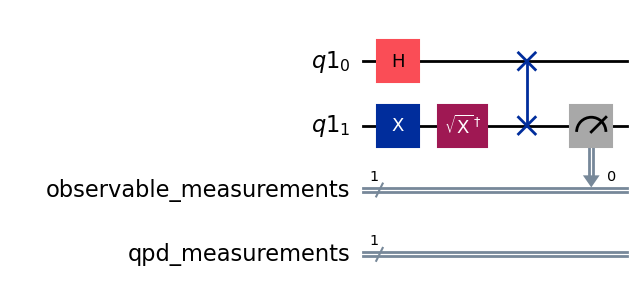

In [50]:
subexperiments[0][5].draw()

In [51]:
from qiskit import qpy
import os

os.makedirs("saved_data/subcircuits", exist_ok=True)

for key, circuits in subexperiments.items():
    for i, circuit in enumerate(circuits):
        with open(f"saved_data/subcircuits/group_{key}_{i}.qpy", "wb") as f:
            qpy.dump(circuit, f)


In [26]:
# Set a backend to use and transpile the subexperiments
backend = FakeManilaV2()
pass_manager = generate_preset_pass_manager(
    optimization_level=1, backend=backend
)
isa_subexperiments = {
    label: pass_manager.run(partition_subexpts)
    for label, partition_subexpts in circuits_dict.items()
}
 
# Submit each partition's subexperiments to the Qiskit Runtime Sampler
# primitive, in a single batch so that the jobs will run back-to-back.
with Batch(backend=backend) as batch:
    sampler = SamplerV2(mode=batch)
    jobs = {
        label: sampler.run(subsystem_subexpts, shots=2**12)
        for label, subsystem_subexpts in isa_subexperiments.items()
    }
    # Retrieve results
    results = {label: job.result() for label, job in jobs.items()}

In [27]:
import json
os.makedirs("saved_data/subobservables", exist_ok=True)
for k,o in subobservables.items():
    with open("saved_data/subobservables/objective"+str(k)+".json", "w") as f:
        json.dump(o.to_labels(), f)

In [28]:
os.makedirs("saved_data/coefficients", exist_ok=True)

rewritten_coefficients = []

for coefficient in coefficients:
    rewritten_coefficients.append((coefficient[0], coefficient[1].EXACT.value))

rewritten_coefficients

with open("saved_data/coefficients/coefficients.json", "w") as f:
    json.dump(rewritten_coefficients, f)

In [29]:
reconstructed_expval_terms = reconstruct_expectation_values(
    results,
    coefficients,
    objectives,
)
# Apply the coefficients of the original observable
reconstructed_expval = np.dot(reconstructed_expval_terms, observable.coeffs)
 
 
# Compute the exact expectation value using the `qiskit_aer` package.
estimator = EstimatorV2()
exact_expval = estimator.run([(qc_0, observable)]).result()[0].data.evs
print(
    f"Reconstructed expectation value: {np.real(np.round(reconstructed_expval, 3))}"
)
print(f"Exact expectation value: {np.round(exact_expval, 3)}")
print(
    f"Error in estimation: {np.real(np.round(reconstructed_expval-exact_expval, 3))}"
)
print(
    f"Relative error in estimation: {np.real(np.round((reconstructed_expval-exact_expval) / exact_expval, 8))}"
)

Reconstructed expectation value: 0.053
Exact expectation value: 0.0
Error in estimation: 0.053
Relative error in estimation: inf


/var/folders/l8/z9twtlsx6815m7383kbwwymm0000gn/T/ipykernel_67800/66081791.py:21: RuntimeWarning: divide by zero encountered in divide
  f"Relative error in estimation: {np.real(np.round((reconstructed_expval-exact_expval) / exact_expval, 8))}"
/var/folders/l8/z9twtlsx6815m7383kbwwymm0000gn/T/ipykernel_67800/66081791.py:21: RuntimeWarning: invalid value encountered in divide
  f"Relative error in estimation: {np.real(np.round((reconstructed_expval-exact_expval) / exact_expval, 8))}"


In [30]:
!pip list

Package               Version
--------------------- ---------
annotated-types       0.6.0
appnope               0.1.4
asttokens             2.4.1
certifi               2024.8.30
cffi                  1.16.0
charset-normalizer    3.3.2
comm                  0.2.2
contourpy             1.2.1
cryptography          42.0.5
cycler                0.12.1
debugpy               1.8.1
decorator             5.1.1
dill                  0.3.8
exceptiongroup        1.2.0
executing             2.0.1
fonttools             4.51.0
ibm-cloud-sdk-core    3.19.2
ibm-platform-services 0.53.2
idna                  3.7
importlib_metadata    7.1.0
ipykernel             6.29.3
ipython               8.22.2
jedi                  0.19.1
jupyter_client        8.6.1
jupyter_core          5.7.2
kiwisolver            1.4.5
matplotlib            3.8.4
matplotlib-inline     0.1.6
mpmath                1.3.0
munkres               1.1.4
nest_asyncio          1.6.0
networkx              3.3
numpy                 1.26.4
pack